In [115]:
import pandas as pd
import numpy as np

In [116]:
from warnings import filterwarnings
filterwarnings('ignore')

In [117]:
df = pd.read_csv('diabetes_clinical_records.csv')

In [118]:
df.head()

,PatientID,Age,Gender,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,SmokingStatus,FamilyHistory,DiabetesRiskScore,DiabetesDiagnosis
0,PT_00001,56,Female,19.2,111,114,5,1,Never,1,30.429557,1
1,PT_00002,69,Female,30.7,148,180,14,7,Never,0,21.174730,0
2,PT_00003,46,Female,20.7,125,71,7,4,Current,1,31.004533,1
3,PT_00004,32,Male,31.0,128,145,3,4,Never,1,35.756383,1
4,PT_00005,60,Male,24.6,140,94,2,6,Former,0,23.552142,0


### Quick Statistics

In [119]:
df.shape

(10000, 12)

In [120]:
df.describe()

,Age,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,FamilyHistory,DiabetesRiskScore,DiabetesDiagnosis
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.798400,25.168800,119.490900,102.191000,9.851100,3.473400,0.300800,25.915353,0.536000
std,17.903223,4.586149,15.200376,25.963234,9.419087,2.300439,0.458629,9.117956,0.498727
min,18.000000,18.000000,70.000000,70.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,21.600000,109.000000,79.000000,2.000000,1.000000,0.000000,19.653878,0.000000
50%,49.000000,25.000000,119.000000,100.000000,7.000000,3.000000,0.000000,25.870307,1.000000
75%,64.000000,28.300000,130.000000,120.000000,14.000000,5.000000,1.000000,32.054231,1.000000
max,79.000000,40.000000,179.000000,207.000000,50.000000,7.000000,1.000000,58.490552,1.000000


In [121]:
df.describe(include='object')

,PatientID,Gender,SmokingStatus
count,10000,10000,10000
unique,10000,2,3
top,PT_00001,Female,Never
freq,1,5131,6035


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          10000 non-null  object 
 1   Age                10000 non-null  int64  
 2   Gender             10000 non-null  object 
 3   BMI                10000 non-null  float64
 4   BloodPressure      10000 non-null  int64  
 5   Glucose            10000 non-null  int64  
 6   Insulin            10000 non-null  int64  
 7   ExerciseDays       10000 non-null  int64  
 8   SmokingStatus      10000 non-null  object 
 9   FamilyHistory      10000 non-null  int64  
 10  DiabetesRiskScore  10000 non-null  float64
 11  DiabetesDiagnosis  10000 non-null  int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [123]:
df.isna().sum()

PatientID            0
Age                  0
Gender               0
BMI                  0
BloodPressure        0
Glucose              0
Insulin              0
ExerciseDays         0
SmokingStatus        0
FamilyHistory        0
DiabetesRiskScore    0
DiabetesDiagnosis    0
dtype: int64

In [124]:
# Make PatientID an index in the data set

df.set_index('PatientID', inplace=True )

In [125]:
df.head()

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,SmokingStatus,FamilyHistory,DiabetesRiskScore,DiabetesDiagnosis
PatientID,,,,,,,,,,,
PT_00001,56,Female,19.2,111,114,5,1,Never,1,30.429557,1
PT_00002,69,Female,30.7,148,180,14,7,Never,0,21.174730,0
PT_00003,46,Female,20.7,125,71,7,4,Current,1,31.004533,1
PT_00004,32,Male,31.0,128,145,3,4,Never,1,35.756383,1
PT_00005,60,Male,24.6,140,94,2,6,Former,0,23.552142,0


In [126]:
df['DiabetesDiagnosis'].value_counts()

DiabetesDiagnosis
1    5360
0    4640
Name: count, dtype: int64

In [127]:
# Create a copy of the original dataset (df) for reference purpose

df_copy = df.copy()

In [128]:
df_copy.head()

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,SmokingStatus,FamilyHistory,DiabetesRiskScore,DiabetesDiagnosis
PatientID,,,,,,,,,,,
PT_00001,56,Female,19.2,111,114,5,1,Never,1,30.429557,1
PT_00002,69,Female,30.7,148,180,14,7,Never,0,21.174730,0
PT_00003,46,Female,20.7,125,71,7,4,Current,1,31.004533,1
PT_00004,32,Male,31.0,128,145,3,4,Never,1,35.756383,1
PT_00005,60,Male,24.6,140,94,2,6,Former,0,23.552142,0


In [129]:
df.head()

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,SmokingStatus,FamilyHistory,DiabetesRiskScore,DiabetesDiagnosis
PatientID,,,,,,,,,,,
PT_00001,56,Female,19.2,111,114,5,1,Never,1,30.429557,1
PT_00002,69,Female,30.7,148,180,14,7,Never,0,21.174730,0
PT_00003,46,Female,20.7,125,71,7,4,Current,1,31.004533,1
PT_00004,32,Male,31.0,128,145,3,4,Never,1,35.756383,1
PT_00005,60,Male,24.6,140,94,2,6,Former,0,23.552142,0


In [130]:
# Generate numerical columns from the data

num_cols = df.select_dtypes(include=['int64', 'float64'])

In [131]:
display(num_cols)

,Age,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,FamilyHistory,DiabetesRiskScore,DiabetesDiagnosis
PatientID,,,,,,,,,
PT_00001,56,19.2,111,114,5,1,1,30.429557,1
PT_00002,69,30.7,148,180,14,7,0,21.174730,0
PT_00003,46,20.7,125,71,7,4,1,31.004533,1
PT_00004,32,31.0,128,145,3,4,1,35.756383,1
PT_00005,60,24.6,140,94,2,6,0,23.552142,0
...,...,...,...,...,...,...,...,...,...
PT_09996,38,27.3,130,70,3,3,1,25.316167,1
PT_09997,23,33.0,116,184,16,0,1,50.648347,1
PT_09998,18,26.0,91,142,2,0,0,35.656292,1


In [132]:
num_cols.head()

,Age,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,FamilyHistory,DiabetesRiskScore,DiabetesDiagnosis
PatientID,,,,,,,,,
PT_00001,56,19.2,111,114,5,1,1,30.429557,1
PT_00002,69,30.7,148,180,14,7,0,21.174730,0
PT_00003,46,20.7,125,71,7,4,1,31.004533,1
PT_00004,32,31.0,128,145,3,4,1,35.756383,1
PT_00005,60,24.6,140,94,2,6,0,23.552142,0


In [133]:
# Generate the correlation of all features with the target (DiabetesDiagnosis)
num_cols.corr()

,Age,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,FamilyHistory,DiabetesRiskScore,DiabetesDiagnosis
Age,1.000000,0.008009,0.000321,-0.007673,0.005062,-0.008255,0.003647,0.099258,0.084741
BMI,0.008009,1.000000,0.009906,0.013768,0.023621,0.001366,0.005779,0.156098,0.132935
BloodPressure,0.000321,0.009906,1.000000,-0.008670,-0.006500,0.005231,0.009918,0.011455,0.000815
Glucose,-0.007673,0.013768,-0.008670,1.000000,-0.001562,0.011222,0.007513,0.430979,0.337849
Insulin,0.005062,0.023621,-0.006500,-0.001562,1.000000,0.005432,-0.004911,-0.016911,-0.012261
ExerciseDays,-0.008255,0.001366,0.005231,0.011222,0.005432,1.000000,0.002466,0.002603,-0.005790
FamilyHistory,0.003647,0.005779,0.009918,0.007513,-0.004911,0.002466,1.000000,0.107547,0.082950
DiabetesRiskScore,0.099258,0.156098,0.011455,0.430979,-0.016911,0.002603,0.107547,1.000000,0.799825
DiabetesDiagnosis,0.084741,0.132935,0.000815,0.337849,-0.012261,-0.005790,0.082950,0.799825,1.000000


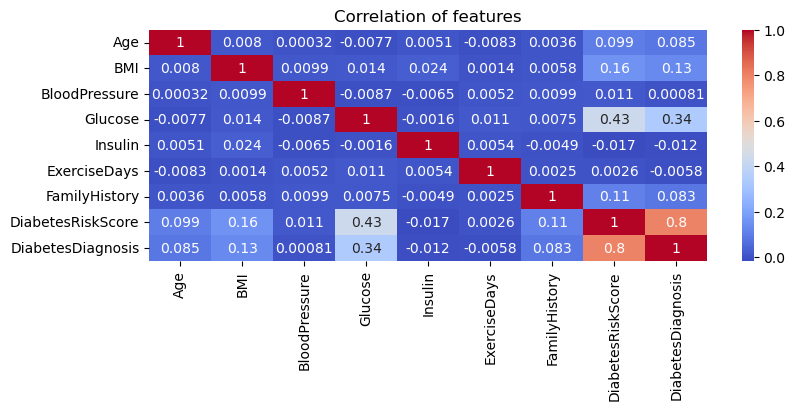

In [134]:
# Heatmap to visualize correlation


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,3))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation of features")
plt.show()

## Data Preprocessing

In data preprocessing, Data Encoding and Scaling are used

- Data Encoding - Converting categorical variables into numerical variables
- Encoding Techniques: Label Encoder and One-Hot Encoding

#### Label Encoding
Is used when there is a sense or order or hierarchy in your dataset.

#### One-Hot Encoding
Is used when there is no bit of hierarchy in the dataset. However, it encodes in binary format, hence creating multiple other features to the dataset

- Scaling  - Using certain statistical measures to normalize all numerical variables for prediction.

In [135]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [136]:
# Initialize LabelEncoder

le = LabelEncoder()

In [137]:
df['Gender']=le.fit_transform(df['Gender'])
df['SmokingStatus'] = le.fit_transform(df['SmokingStatus'])

In [138]:
df.head()

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,SmokingStatus,FamilyHistory,DiabetesRiskScore,DiabetesDiagnosis
PatientID,,,,,,,,,,,
PT_00001,56,0,19.2,111,114,5,1,2,1,30.429557,1
PT_00002,69,0,30.7,148,180,14,7,2,0,21.174730,0
PT_00003,46,0,20.7,125,71,7,4,0,1,31.004533,1
PT_00004,32,1,31.0,128,145,3,4,2,1,35.756383,1
PT_00005,60,1,24.6,140,94,2,6,1,0,23.552142,0


In [139]:
# # Initialize OneHotEncoder

# ohe = OneHotEncoder

In [140]:
# df['Gender'] = ohe.fit_transform(df['Gender'])
# df['SmokingStatus'] = ohe.fit_transform(df['SmokingStatus'])

In [141]:
# Split Data into features and target

X = df.drop('DiabetesDiagnosis', axis=1)
y = df['DiabetesDiagnosis']


In [142]:
X.head()

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,ExerciseDays,SmokingStatus,FamilyHistory,DiabetesRiskScore
PatientID,,,,,,,,,,
PT_00001,56,0,19.2,111,114,5,1,2,1,30.429557
PT_00002,69,0,30.7,148,180,14,7,2,0,21.174730
PT_00003,46,0,20.7,125,71,7,4,0,1,31.004533
PT_00004,32,1,31.0,128,145,3,4,2,1,35.756383
PT_00005,60,1,24.6,140,94,2,6,1,0,23.552142


In [143]:
y.head()

PatientID
PT_00001    1
PT_00002    0
PT_00003    1
PT_00004    1
PT_00005    0
Name: DiabetesDiagnosis, dtype: int64

In [144]:
# Scale features and split

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

In [145]:
X = scaler.fit_transform(X)

In [146]:
display(X)

array([[ 0.4022717 , -0.9741344 , -1.30154927, ...,  0.74570685,
         1.52462064,  0.49511427],
       [ 1.12843423, -0.9741344 ,  1.20612674, ...,  0.74570685,
        -0.65590087, -0.51994763],
       [-0.15631486, -0.9741344 , -0.97446109, ..., -1.74454811,
         1.52462064,  0.55817716],
       ...,
       [-1.72035724,  1.02655239,  0.18125046, ..., -0.49942063,
        -0.65590087,  1.06837829],
       [-1.55278127,  1.02655239, -0.62556704, ...,  0.74570685,
        -0.65590087,  0.35659493],
       [-1.16177068, -0.9741344 , -0.12403184, ...,  0.74570685,
        -0.65590087, -1.95396147]])

# Train-Test Split

Splitting your data into two parts: training data and testing data.
Usually done in 80% to 20% split proportion

In [147]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
print(f'Original data: {df.shape}')
print(f'Full features: {X.shape}')
print(f'Full target: {y.shape}')
print(f'Feature Training data: {X_train.shape}')
print(f'Target training data: {y_train.shape}')
print(f'Feature testing data: {X_test.shape}')
print(f'Target testing data: {y_test.shape} ')

Original data: (10000, 11)
Full features: (10000, 10)
Full target: (10000,)
Feature Training data: (8000, 10)
Target training data: (8000,)
Feature testing data: (2000, 10)
Target testing data: (2000,) 


# Train our Models

- Classification Models
    - Logistic Regression
    - Random Forest Classifier
    - XGBoost Classifier
    - SVM (Support Vector Machine)/ SVC (Support vector Classification)
    - Naive Baye's Theorem
- Regression Models
    - Linear Regression
    - Random Forest Regressor
    - XGBoost
    - Decision Tree

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [150]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [151]:
# Define all models in a Function

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'SVM': SVC(probability=True),
    'Naive Bayes': GaussianNB(),
    'DecisionTree': RandomForestClassifier(max_depth=3)
}


for name, model in models.items():
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f'{name} Train_Accuracy: {train_score:.2f}')
    print(f'{name} Train_Accuracy: {test_score:.2f}')

Logistic Regression Train_Accuracy: 1.00
Logistic Regression Train_Accuracy: 1.00
Random Forest Train_Accuracy: 1.00
Random Forest Train_Accuracy: 1.00
XGBoost Train_Accuracy: 1.00
XGBoost Train_Accuracy: 1.00
SVM Train_Accuracy: 0.99
SVM Train_Accuracy: 0.99
Naive Bayes Train_Accuracy: 0.95
Naive Bayes Train_Accuracy: 0.94
DecisionTree Train_Accuracy: 1.00
DecisionTree Train_Accuracy: 1.00


##### Model Evaluation

In [152]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [153]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{name} Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

Logistic Regression Accuracy: 0.9960
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       922
           1       1.00      0.99      1.00      1078

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

[[ 920    2]
 [   6 1072]]
Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       922
           1       1.00      1.00      1.00      1078

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

[[ 922    0]
 [   0 1078]]
XGBoost Accuracy: 0.9980
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       922
           1       1.00      1.00      1.00      1078

    accuracy                       

In [164]:
model_rf = RandomForestClassifier(n_estimators=100)

model_rf.fit(X_train, y_train)
score = model_rf.score(X_test, y_test)
print(f'Accuracy: {score:.2f}')

Accuracy: 1.00


In [167]:
rf_pred = model_rf.predict(X_test)
print("Classification Report:", classification_report(y_test, y_pred))

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       922
           1       1.00      1.00      1.00      1078

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



##### Save the model

In [168]:
import joblib
import pickle

joblib.dump(model_rf, 'diabetes_model.pkl')

['diabetes_model.pkl']

#### Prediction

In [185]:
# Load your saved model

rf_model = joblib.load('diabetes_model.pkl')


# Create a Sample data
sample_input = {
    'Age': 56,
    'Gender': 'Female',
    'BMI': 30.7,
    'BloodPressure': 146,
    'Glucoe': 175,
    'Insulin': 13,
    'ExerciseDays': 7,
    'SmokingStatus': 'Never',
    'FamilyHistory': 0,
    'DiabetesRiskScore': 21.37
}


# Convert to Data Frame
input_df = pd.DataFrame([sample_input])


# Mapping Gender and SmokingStatus
input_df['Gender'] = input_df['Gender'].map({'Male':1, 'Female':0})
input_df['SmokingStatus'] = input_df['SmokingStatus'].map({'Never':0, 'Former':1, 'Current':2})

In [186]:
input_df

,Age,Gender,BMI,BloodPressure,Glucoe,Insulin,ExerciseDays,SmokingStatus,FamilyHistory,DiabetesRiskScore
0,56,0,30.7,146,175,13,7,0,0,21.37


In [187]:
prediction = rf_model.predict(input_df)
probability = rf_model.predict_proba(input_df)

In [189]:
# Show prediction result for this data supplied


print(f'Predicted Diabetes Status: {'Positive' if prediction [0] == 1 else 'Negative'}')
print(f'Probability: {probability[0][1]*100:.2f}% chance of diabetes')

Predicted Diabetes Status: Positive
Probability: 98.00% chance of diabetes


In [184]:
df_copy['DiabetesDiagnosis'].value_counts()

DiabetesDiagnosis
1    5360
0    4640
Name: count, dtype: int64